In [4]:
# ==============================================
# 作业1：深度学习基础 — 线性代数、概率、反向传播、Softmax、逻辑回归
# 文件名：HW01-学号-姓名.ipynb
# ==============================================
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import torch
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

2 线性代数和 NDArray
2.1 理论计算题1. 点积 a·b = 2×1 + (-1)×4 + 3×(-2) = -8
2. A(2×3) × B(3×2) = 2×2 矩阵
   A×B = [[ 7  5]
          [ 1 -2]]
3. a 的 F范数：√(2² + (-1)² + 3²) = √14

In [5]:
# ========== 2.2 线性代数编程题 ==========
# 1. 创建 3×4 标准正态分布随机矩阵
X = np.random.randn(3, 4)  
print("1. 3×4标准正态矩阵 X：")
print(X)

# 2. 创建 4×2 全1矩阵
Y = np.ones((4, 2))  
print("\n2. 4×2全1矩阵 Y：")
print(Y)

# 3. 矩阵乘法 Z = X @ Y
Z = np.dot(X, Y)  
print("\n3. Z = X @ Y：")
print(Z)
print("Z 的形状：", Z.shape)

# 4. 输出 Z[第一行,第二列] 和 Z[第二行所有元素]
print("\n4. 第一行第二列元素：", Z[0, 1])
print("第二行所有元素：", Z[1, :])

# 5. 计算 Z 的 Frobenius 范数
f_norm = np.linalg.norm(Z, 'fro')  
print("\n5. Z 的 Frobenius 范数：", f_norm)

1. 3×4标准正态矩阵 X：
[[-1.10429761  0.12382834  1.60369627  0.41061079]
 [-1.92563488  2.10030818  0.52661418 -1.37052807]
 [ 0.67332052  1.41529262 -0.63724971  1.76221517]]

2. 4×2全1矩阵 Y：
[[1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]]

3. Z = X @ Y：
[[ 1.0338378   1.0338378 ]
 [-0.66924059 -0.66924059]
 [ 3.2135786   3.2135786 ]]
Z 的形状： (3, 2)

4. 第一行第二列元素： 1.03383779730664
第二行所有元素： [-0.66924059 -0.66924059]

5. Z 的 Frobenius 范数： 4.866989000157624


3 概率与统计
3.1 贝叶斯理论计算

患病率 P(A)=0.001，未患病 P(¬A)=0.999
灵敏度 P(+|A)=0.99，假阳性 P(+|¬A)=0.02

P(A|+) = 0.99×0.001 / (0.99×0.001 + 0.02×0.999) ≈ 4.72%

3.2 中心极限定理

C:\Users\HP\miniconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20013 (\N{CJK UNIFIED IDEOGRAPH-4E2D}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\HP\miniconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24515 (\N{CJK UNIFIED IDEOGRAPH-5FC3}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\HP\miniconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26497 (\N{CJK UNIFIED IDEOGRAPH-6781}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\HP\miniconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 38480 (\N{CJK UNIFIED IDEOGRAPH-9650}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\HP\miniconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 23450 (\N{CJK UNIFIED IDEOGRAPH-5B9A}) missing from font(s) DejaVu Sans.
  fig.c

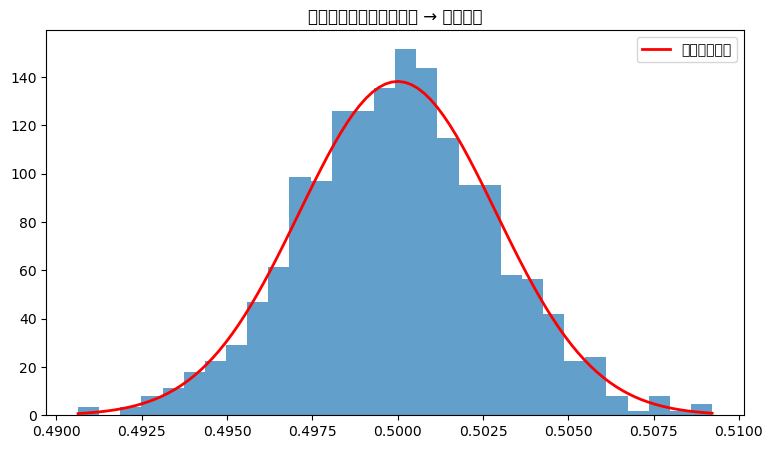

3. 均值的实际方差： 8.280740294291152e-06
理论方差： 8.333333333333334e-06


In [6]:
# ========== 3.2 中心极限定理 ==========
n = 10000    # 每组样本数
m = 1000     # 抽样次数
means = []

# 1. 生成均匀分布样本并计算均值
for i in range(m):
    sample = np.random.uniform(0, 1, n)  
    means.append(np.mean(sample))       
means = np.array(means)

# 2. 绘制直方图 + 理论正态分布
plt.figure(figsize=(9,5))
plt.hist(means, bins=30, density=True, alpha=0.7)
mu = 0.5
var = 1 / (12 * n)  
sigma = np.sqrt(var)
x = np.linspace(means.min(), means.max(), 100)
plt.plot(x, norm.pdf(x, mu, sigma), 'r-', linewidth=2, label='理论正态分布')
plt.title("中心极限定理：均匀分布 → 正态分布")
plt.legend()
plt.show()

# 3. 输出实际方差
print("3. 均值的实际方差：", np.var(means))
print("理论方差：", var)

4 导数、反向传播
4.1 理论题答案

z = (2w1 + w2 - 3)²
∂z/∂w1 = 4*(2w1+w2-3)
∂z/∂w2 = 2*(2w1+w2-3)

代入 w1=0.5, w2=1：
∂z/∂w1 = -4，∂z/∂w2 = -2
梯度：[-4, -2]

In [7]:
# ========== 4.2 手动反向传播 ==========
x = 2
w1 = 1.5
w2 = 0.5

# 前向传播
a = x * w1
b = a + w2
L = b ** 2
print("前向结果 Loss L =", L)

# 手动链式法则求梯度
dL_db = 2 * b
dL_dw1 = dL_db * x
dL_dw2 = dL_db
print("手动梯度：dw1 =", dL_dw1, "  dw2 =", dL_dw2)

# PyTorch 自动微分验证
w1_t = torch.tensor(1.5, requires_grad=True)
w2_t = torch.tensor(0.5, requires_grad=True)
x_t = torch.tensor(2.0)

a_t = x_t * w1_t
b_t = a_t + w2_t
L_t = b_t ** 2
L_t.backward()

print("自动微分梯度：dw1 =", w1_t.grad.item(), " dw2 =", w2_t.grad.item())

前向结果 Loss L = 12.25
手动梯度：dw1 = 14.0   dw2 = 7.0
自动微分梯度：dw1 = 14.0  dw2 = 7.0


5 Softmax 回归（MNIST 分类）
5.1 理论题答案

L = 1/n ∑(y_i - (w x_i + b))²
∂L/∂w = (-2/n) ∑ x_i (y_i - w x_i - b)
∂L/∂b = (-2/n) ∑ (y_i - w x_i - b)

5.2 Softmax 从零实现

In [8]:
# ========== 5.2 Softmax 回归 ==========
# 1. 加载手写数字数据集
data = load_digits()
X = data.data          # (1797,64)
y = data.target.reshape(-1,1)

# 2. One-hot 编码
enc = OneHotEncoder(sparse_output=False)
y_onehot = enc.fit_transform(y)
X_train, X_test, y_train, y_test = train_test_split(X, y_onehot, test_size=0.2)

# 3. Softmax 函数（防止溢出）
def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

# 交叉熵损失
def cross_entropy(y_pred, y_true):
    return -np.mean(np.sum(y_true * np.log(y_pred + 1e-8), axis=1))

# 4. 训练参数
input_dim = 64
num_classes = 10
lr = 0.1
epochs = 50
batch_size = 32

W = np.random.randn(input_dim, num_classes) * 0.01
b = np.zeros((1, num_classes))

# 小批量梯度下降
num_batches = len(X_train) // batch_size
for epoch in range(epochs):
    loss = 0
    for i in range(num_batches):
        Xb = X_train[i*batch_size : (i+1)*batch_size]
        yb = y_train[i*batch_size : (i+1)*batch_size]
        
        yp = softmax(Xb @ W + b)
        loss += cross_entropy(yp, yb)
        
        # 反向传播
        dz = yp - yb
        dW = Xb.T @ dz / batch_size
        db = np.mean(dz, axis=0)
        
        # 更新参数
        W -= lr * dW
        b -= lr * db
    
    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}, Loss: {loss/num_batches:.4f}")

# 5. 测试集准确率
def accuracy(X, y, W, b):
    pred = np.argmax(softmax(X @ W + b), axis=1)
    true = np.argmax(y, axis=1)
    return np.mean(pred == true)

acc = accuracy(X_test, y_test, W, b)
print("\n测试集准确率：", acc)

Epoch 10, Loss: 0.2581
Epoch 20, Loss: 0.0579
Epoch 30, Loss: 0.0114
Epoch 40, Loss: 0.0008
Epoch 50, Loss: 0.0003

测试集准确率： 0.9611111111111111


6 最大似然估计 & 逻辑回归
6.1 理论题答案

1. 似然函数：
L(μ,σ²)=∏(1/√(2πσ²)) exp( −(xi−μ)²/(2σ²) )

2. μ的MLE：样本均值
3. σ²的MLE：1/n ∑(xi−x̄)²

Iter 0, Loss: 0.6529
Iter 100, Loss: 0.3091
Iter 200, Loss: 0.2163
Iter 300, Loss: 0.1716
Iter 400, Loss: 0.1451
Iter 500, Loss: 0.1274
Iter 600, Loss: 0.1147
Iter 700, Loss: 0.1051
Iter 800, Loss: 0.0975
Iter 900, Loss: 0.0914

测试集准确率： 0.98


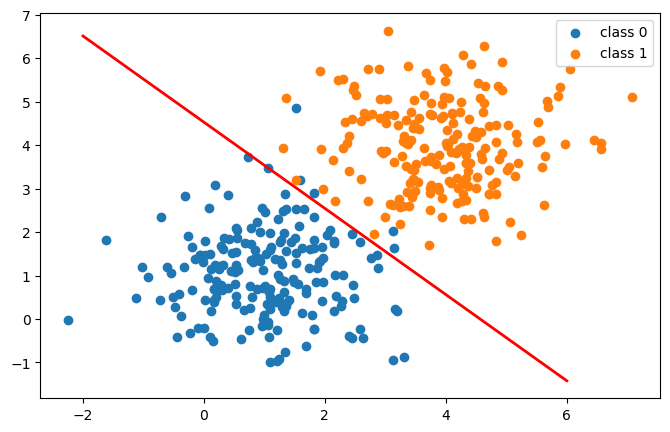

In [9]:
# ========== 6.2 逻辑回归 ==========
# 1. 生成线性可分数据
np.random.seed(42)
n = 200
X0 = np.random.randn(n, 2) + [1, 1]   # 类别0
X1 = np.random.randn(n, 2) + [4, 4]   # 类别1
X = np.vstack([X0, X1])
y = np.hstack([np.zeros(n), np.ones(n)])

# 划分训练集、测试集（测试集100个）
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=100, random_state=42
)

# 2. Sigmoid函数
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# 二元交叉熵
def bce_loss(y_pred, y_true):
    return -np.mean(y_true*np.log(y_pred+1e-8) + (1-y_true)*np.log(1-y_pred+1e-8))

# 3. 梯度下降训练
w = np.random.randn(2)
b = 0.0
lr = 0.1
iters = 1000

for i in range(iters):
    z = X_train @ w + b
    yp = sigmoid(z)
    loss = bce_loss(yp, y_train)
    
    dz = yp - y_train
    dw = X_train.T @ dz / len(X_train)
    db = np.mean(dz)
    
    w -= lr * dw
    b -= lr * db
    
    if i % 100 == 0:
        print(f"Iter {i}, Loss: {loss:.4f}")

# 4. 测试准确率
def test_acc(X, y, w, b):
    pred = sigmoid(X @ w + b) >= 0.5
    return np.mean(pred == y)

acc = test_acc(X_test, y_test, w, b)
print("\n测试集准确率：", acc)

# 绘制决策边界
plt.figure(figsize=(8,5))
plt.scatter(X0[:,0], X0[:,1], label="class 0")
plt.scatter(X1[:,0], X1[:,1], label="class 1")
x_line = np.array([-2, 6])
y_line = -(w[0]*x_line + b) / w[1]
plt.plot(x_line, y_line, 'r-', linewidth=2)
plt.legend()
plt.show()